# Đánh giá DUC TextRank theo tập câu chuẩn

## tl;dr

Notebook đối chiếu các câu trong `data/output/duc-textrank-pipeline` với `data/DUC_SUM`, bỏ qua reference rỗng, in preview, ghi kết quả đầy đủ ra `data/output/duc-textrank-evaluation.csv` và xuất biểu đồ tổng hợp ra `data/output/duc-textrank-evaluation.png`. Kết quả gồm Precision@K, Recall@K, F1@K và Hit@K theo topic cùng macro-average theo K.

## Context & Methods

### Key Assumptions

- Hai câu trùng nhau khi nội dung sau khi `casefold` và gom khoảng trắng giống hệt nhau; metadata `docid`/`num` không tham gia đối chiếu.
- Mỗi topic chỉ có dòng tại K nếu output có ít nhất K câu. Macro-average tại K chỉ tính trên các topic đủ điều kiện đó.
- Output pipeline đã sắp câu được chọn về thứ tự xuất hiện, không giữ toàn bộ ranking PageRank. Do đó notebook không báo cáo MAP/NDCG và K phản ánh thứ tự đang được lưu trong file output, không phải ranking gốc.

### Định nghĩa ký hiệu và công thức

Với một topic và một giá trị $K$:

- $P_K$ là tập $K$ câu đầu tiên trong output của hệ thống.
- $R$ là tập câu chuẩn trong `DUC_SUM`.
- $TP_K = |P_K \cap R|$ là số câu trong $P_K$ khớp chính xác với câu chuẩn sau bước chuẩn hóa.

Độ chính xác tại $K$ đo tỷ lệ câu trích đúng trong số câu hệ thống đã chọn:

$$\mathrm{Precision@K} = \frac{TP_K}{|P_K|} = \frac{TP_K}{K}$$

Độ phủ tại $K$ đo tỷ lệ câu chuẩn đã được hệ thống tìm thấy:

$$\mathrm{Recall@K} = \frac{TP_K}{|R|}$$

F1@K là trung bình điều hòa của Precision@K và Recall@K, chỉ lớn khi cả độ chính xác lẫn độ phủ cùng tốt:

$$\mathrm{F1@K} = 2 \times \frac{\mathrm{Precision@K} \times \mathrm{Recall@K}}{\mathrm{Precision@K} + \mathrm{Recall@K}}$$

Hit@K chỉ kiểm tra trong $K$ câu đầu có ít nhất một câu đúng hay không:

$$\mathrm{Hit@K} = \begin{cases}1, & TP_K > 0 \\ 0, & TP_K = 0\end{cases}$$

Với $E_K$ là tập topic có ít nhất $K$ câu output, macro-average của metric $m$ tại $K$ được tính bằng:

$$\mathrm{MacroAvg}_m@K = \frac{1}{|E_K|} \sum_{t \in E_K} m_t@K$$

Vì $|E_K|$ giảm khi $K$ tăng, các điểm macro ở những giá trị $K$ khác nhau có thể được tính trên các tập topic khác nhau. Cần đọc biểu đồ metric cùng với `eligible_topics`, tránh kết luận rằng metric thay đổi hoàn toàn do chất lượng mô hình.

In [6]:
import csv
import re
import matplotlib.pyplot as plt
from collections import defaultdict
from html.parser import HTMLParser
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

PREDICTION_DIR = PROJECT_ROOT / 'data' / 'output' / 'duc-textrank-pipeline'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
CSV_PATH = PROJECT_ROOT / 'data' / 'output' / 'duc-textrank-evaluation.csv'
FIGURE_PATH = PROJECT_ROOT / 'data' / 'output' / 'duc-textrank-evaluation.png'

assert PREDICTION_DIR.is_dir(), f'Không tìm thấy prediction: {PREDICTION_DIR}'
assert REFERENCE_DIR.is_dir(), f'Không tìm thấy reference: {REFERENCE_DIR}'
CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f'Prediction: {PREDICTION_DIR}')
print(f'Reference : {REFERENCE_DIR}')
print(f'CSV       : {CSV_PATH}')
print(f'Biểu đồ   : {FIGURE_PATH}')

Prediction: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/duc-textrank-pipeline
Reference : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/DUC_SUM
CSV       : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/duc-textrank-evaluation.csv
Biểu đồ   : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/duc-textrank-evaluation.png


## Data

### 1. Parse và chuẩn hóa câu

In [7]:
WHITESPACE_PATTERN = re.compile(r'\s+')


class SentenceContentParser(HTMLParser):
    def __init__(self):
        super().__init__(convert_charrefs=True)
        self.sentences = []
        self.current_parts = None

    def handle_starttag(self, tag, attrs):
        if tag.casefold() == 's':
            self.current_parts = []

    def handle_data(self, data):
        if self.current_parts is not None:
            self.current_parts.append(data)

    def handle_endtag(self, tag):
        if tag.casefold() == 's' and self.current_parts is not None:
            content = ''.join(self.current_parts)
            if content.strip():
                self.sentences.append(content)
            self.current_parts = None


def normalize_sentence(content):
    return WHITESPACE_PATTERN.sub(' ', content).strip().casefold()


def read_sentences(path):
    parser = SentenceContentParser()
    parser.feed(path.read_text(encoding='utf-8'))
    parser.close()
    return [normalize_sentence(sentence) for sentence in parser.sentences]

In [8]:
prediction_paths = sorted(path for path in PREDICTION_DIR.iterdir() if path.is_file())
skipped = []
evaluation_data = {}

for prediction_path in prediction_paths:
    reference_path = REFERENCE_DIR / prediction_path.name
    if not prediction_path.read_text(encoding='utf-8').strip():
        skipped.append((prediction_path.name, 'prediction rỗng'))
        continue
    if not reference_path.is_file():
        skipped.append((prediction_path.name, 'thiếu reference'))
        continue
    if not reference_path.read_text(encoding='utf-8').strip():
        skipped.append((prediction_path.name, 'reference rỗng'))
        continue

    predictions = read_sentences(prediction_path)
    references = set(read_sentences(reference_path))
    if not predictions:
        skipped.append((prediction_path.name, 'prediction không có thẻ <s> hợp lệ'))
        continue
    if not references:
        skipped.append((prediction_path.name, 'reference không có thẻ <s> hợp lệ'))
        continue
    evaluation_data[prediction_path.name] = (predictions, references)

assert evaluation_data, 'Không có topic hợp lệ để đánh giá'
print(f'Tổng file prediction: {len(prediction_paths)}')
print(f'Topic được đánh giá: {len(evaluation_data)}')
print(f'Topic bị bỏ qua: {len(skipped)}')
for topic, reason in skipped:
    print(f'  - {topic}: {reason}')

Tổng file prediction: 50
Topic được đánh giá: 34
Topic bị bỏ qua: 16
  - d062j: reference rỗng
  - d067f: reference rỗng
  - d068f: reference rỗng
  - d071f: reference rỗng
  - d072f: reference rỗng
  - d074b: reference rỗng
  - d078b: reference rỗng
  - d084a: reference rỗng
  - d085d: reference rỗng
  - d086d: reference rỗng
  - d090d: reference rỗng
  - d097e: reference rỗng
  - d098e: reference rỗng
  - d104g: reference rỗng
  - d106g: reference rỗng
  - d108g: reference rỗng


## Results

### 2. Tính metric theo topic và K

In [9]:
METRIC_COLUMNS = ('precision_at_k', 'recall_at_k', 'f1_at_k', 'hit_at_k')
topic_rows = []

for topic, (predictions, references) in sorted(evaluation_data.items()):
    matched = 0
    for k, prediction in enumerate(predictions, start=1):
        matched += int(prediction in references)
        precision = matched / k
        recall = matched / len(references)
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        topic_rows.append({
            'row_type': 'topic',
            'topic': topic,
            'k': k,
            'eligible_topics': 1,
            'prediction_count': len(predictions),
            'reference_count': len(references),
            'matched_at_k': matched,
            'precision_at_k': precision,
            'recall_at_k': recall,
            'f1_at_k': f1,
            'hit_at_k': float(matched > 0),
        })

rows_by_k = defaultdict(list)
for row in topic_rows:
    rows_by_k[row['k']].append(row)

macro_rows = []
for k, rows_at_k in sorted(rows_by_k.items()):
    macro_row = {
        'row_type': 'macro',
        'topic': 'ALL',
        'k': k,
        'eligible_topics': len(rows_at_k),
        'prediction_count': '',
        'reference_count': '',
        'matched_at_k': '',
    }
    for metric in METRIC_COLUMNS:
        macro_row[metric] = sum(row[metric] for row in rows_at_k) / len(rows_at_k)
    macro_rows.append(macro_row)

all_rows = topic_rows + macro_rows
fieldnames = [
    'row_type', 'topic', 'k', 'eligible_topics', 'prediction_count',
    'reference_count', 'matched_at_k', *METRIC_COLUMNS,
]
with CSV_PATH.open('w', encoding='utf-8', newline='') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_rows)

print(f'Đã ghi {len(all_rows)} dòng vào {CSV_PATH}')

Đã ghi 252 dòng vào /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/duc-textrank-evaluation.csv


### 3. Trực quan hóa macro-average theo K

Biểu đồ trên thể hiện đồng thời Precision@K, Recall@K, F1@K và Hit@K. Biểu đồ dưới thể hiện số `eligible_topics` thực sự tham gia macro-average ở từng $K$. Hai biểu đồ dùng chung trục $K$ để cho thấy biến động metric có đi kèm thay đổi mẫu đánh giá hay không.

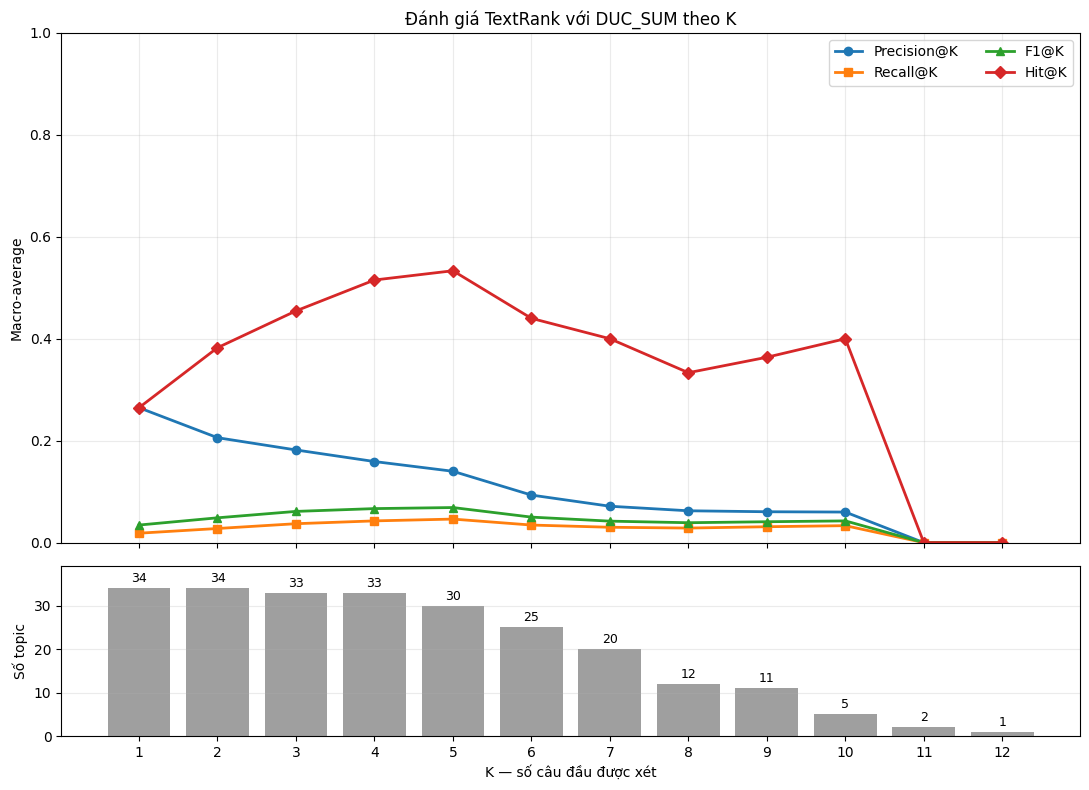

Đã ghi biểu đồ vào /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/duc-textrank-evaluation.png


In [10]:
k_values = [row['k'] for row in macro_rows]
metric_styles = {
    'precision_at_k': ('Precision@K', 'o'),
    'recall_at_k': ('Recall@K', 's'),
    'f1_at_k': ('F1@K', '^'),
    'hit_at_k': ('Hit@K', 'D'),
}

fig, (metric_ax, eligible_ax) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)
for metric, (label, marker) in metric_styles.items():
    metric_ax.plot(
        k_values,
        [row[metric] for row in macro_rows],
        marker=marker,
        linewidth=2,
        label=label,
    )

metric_ax.set_title('Đánh giá TextRank với DUC_SUM theo K')
metric_ax.set_ylabel('Macro-average')
metric_ax.set_ylim(0, 1.0)
metric_ax.grid(axis='both', alpha=0.25)
metric_ax.legend(ncol=2)

eligible_counts = [row['eligible_topics'] for row in macro_rows]
eligible_ax.bar(k_values, eligible_counts, color='tab:gray', alpha=0.75)
for k, count in zip(k_values, eligible_counts):
    eligible_ax.text(k, count + 0.7, str(count), ha='center', va='bottom', fontsize=9)
eligible_ax.set_xlabel('K — số câu đầu được xét')
eligible_ax.set_ylabel('Số topic')
eligible_ax.set_xticks(k_values)
eligible_ax.set_ylim(0, max(eligible_counts) * 1.15)
eligible_ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã ghi biểu đồ vào {FIGURE_PATH}')

In [11]:
def print_table(rows, columns):
    rendered = [[str(row[column]) if not isinstance(row[column], float) else f'{row[column]:.4f}' for column in columns] for row in rows]
    widths = [max(len(column), *(len(values[index]) for values in rendered)) for index, column in enumerate(columns)]
    print(' | '.join(column.ljust(widths[index]) for index, column in enumerate(columns)))
    print('-+-'.join('-' * width for width in widths))
    for values in rendered:
        print(' | '.join(value.ljust(widths[index]) for index, value in enumerate(values)))

preview_columns = ['row_type', 'topic', 'k', 'matched_at_k', *METRIC_COLUMNS]
print('\nPreview 10 dòng theo topic:')
print_table(topic_rows[:10], preview_columns)
print('\nMacro-average theo K:')
print_table(macro_rows, ['k', 'eligible_topics', *METRIC_COLUMNS])


Preview 10 dòng theo topic:
row_type | topic | k | matched_at_k | precision_at_k | recall_at_k | f1_at_k | hit_at_k
---------+-------+---+--------------+----------------+-------------+---------+---------
topic    | d061j | 1 | 1            | 1.0000         | 0.0556      | 0.1053  | 1.0000  
topic    | d061j | 2 | 1            | 0.5000         | 0.0556      | 0.1000  | 1.0000  
topic    | d061j | 3 | 1            | 0.3333         | 0.0556      | 0.0952  | 1.0000  
topic    | d061j | 4 | 2            | 0.5000         | 0.1111      | 0.1818  | 1.0000  
topic    | d061j | 5 | 2            | 0.4000         | 0.1111      | 0.1739  | 1.0000  
topic    | d063j | 1 | 0            | 0.0000         | 0.0000      | 0.0000  | 0.0000  
topic    | d063j | 2 | 0            | 0.0000         | 0.0000      | 0.0000  | 0.0000  
topic    | d063j | 3 | 1            | 0.3333         | 0.0556      | 0.0952  | 1.0000  
topic    | d063j | 4 | 1            | 0.2500         | 0.0556      | 0.0909  | 1.0000  
top

## Takeaways

- Dùng các dòng `topic` trong CSV để phân tích từng file và các dòng `macro` để xem chất lượng trung bình theo K.
- `eligible_topics` giúp diễn giải macro-average khi số câu output không giống nhau giữa các topic; từ $K=3$ trở đi số topic đủ điều kiện bắt đầu giảm.
- Precision thường giảm khi $K$ tăng vì mẫu số là số câu đã chọn, trong khi Recall có thể tăng khi tìm thêm câu chuẩn. F1 dung hòa hai xu hướng này.
- Không chọn $K$ chỉ để làm một metric đạt giá trị cao. Cần xem đồng thời Precision, Recall, F1 và số topic đủ điều kiện.
- Muốn đánh giá MAP/NDCG đúng nghĩa, pipeline cần xuất toàn bộ ranking câu trước MMR/chọn summary.